In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


def sigmoid(x):
    return 1/(1+np.exp(-x))
z = {-10, -5, -2, 0, 2, 5, 10}

for x in z:
    print(f"{x}: {sigmoid(x)} ")


0: 0.5 
2: 0.8807970779778823 
5: 0.9933071490757153 
-10: 4.5397868702434395e-05 
10: 0.9999546021312976 
-5: 0.0066928509242848554 
-2: 0.11920292202211755 


In [6]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
iris = load_iris()
x = iris.data
y = iris.target
mask = y<2
xbin=x[mask]
ybin=y[mask]
X_train, X_test, y_train,y_test= train_test_split(xbin, ybin, test_size=0.2, random_state=42)
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)
model=LogisticRegression(random_state=42)
model.fit(x_scaled, y_train)
y_pred = model.predict(x_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print("=== WYNIKI MODELU ===")
print(f"Accuracy:  {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")

print("\n=== CONFUSION MATRIX (Macierz pomyłek) ===")
print(confusion_matrix(y_test, y_pred))

=== WYNIKI MODELU ===
Accuracy:  1.00
Precision: 1.00
Recall:    1.00

=== CONFUSION MATRIX (Macierz pomyłek) ===
[[12  0]
 [ 0  8]]


=== WARTOŚCI MACIERZY POMYŁEK ===
True Negatives (TN):  12
False Positives (FP): 0
False Negatives (FN): 0
True Positives (TP):  8


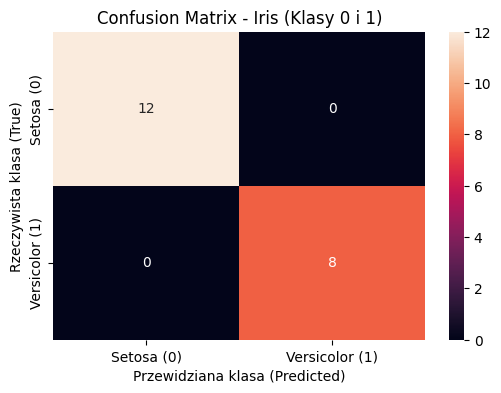

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("=== WARTOŚCI MACIERZY POMYŁEK ===")
print(f"True Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP):  {tp}")

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Setosa (0)', 'Versicolor (1)'],
            yticklabels=['Setosa (0)', 'Versicolor (1)'])

plt.title('Confusion Matrix - Iris (Klasy 0 i 1)')
plt.ylabel('Rzeczywista klasa (True)')
plt.xlabel('Przewidziana klasa (Predicted)')

# Wyświetlenie wykresu
plt.show()